![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Redes Neuronales

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de redes neuronales de una capa y multicapa. El taller está constituido por 4 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción probabilidad de admisión a la universidad

En este taller se usará el conjunto de datos de admisiones a una universidad proveniente de la base de datos de Kaggle. Cada observación contiene la probabilidad de que un estudiante sea admitido por la universidad, dadas distintas variables predictoras como el puntaje del examén TOEFL y GRE, el promedio (GPA), entre otras. El objetivo es predecir la probabilidad de admissión de cada estudiante. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/mohansacharya/graduate-admissions).

In [112]:
import warnings
warnings.filterwarnings('ignore')

In [113]:
# Importación librerías

import numpy as np
import keras 
import pandas as pd
import random
import matplotlib.pyplot as plt
%matplotlib inline

random.seed(42)
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

from sklearn.model_selection import train_test_split
from keras import initializers
from keras import optimizers
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Activation

from sklearn.preprocessing import StandardScaler
from livelossplot import PlotLossesKeras

In [114]:
# Carga de datos de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/universityGraduateAdmissions.csv', index_col=0)
data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,0.92
2,324,107,4,4.0,4.5,8.87,1,0.76
3,316,104,3,3.0,3.5,8.00,1,0.72
4,322,110,3,3.5,2.5,8.67,1,0.80
5,314,103,2,2.0,3.0,8.21,0,0.65


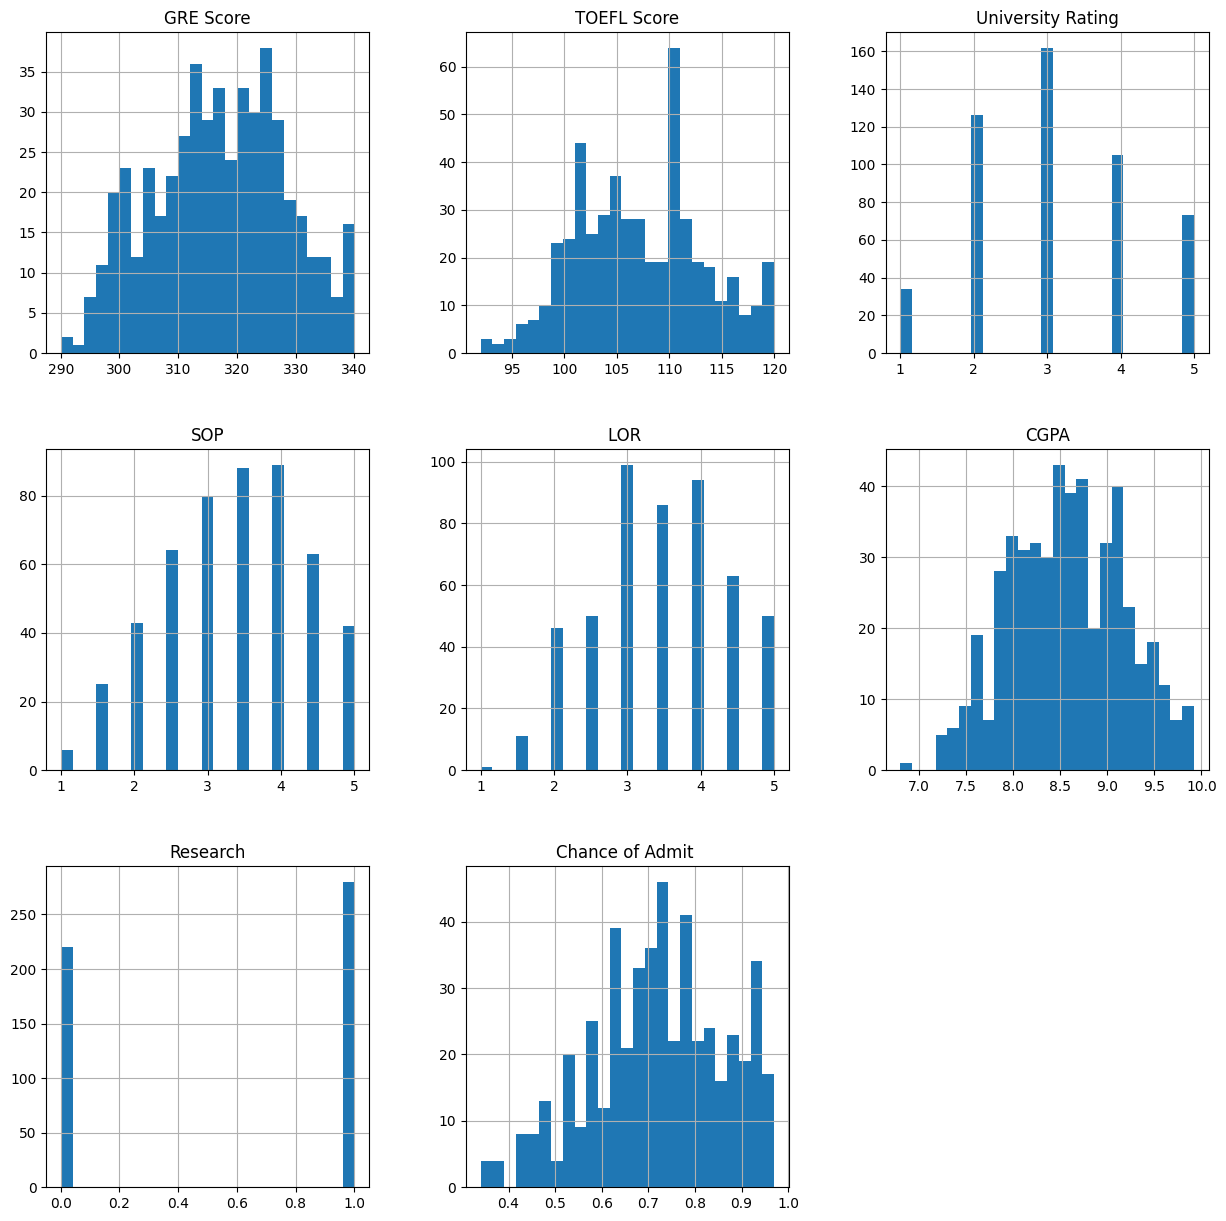

In [115]:
# Hitogramas de las varaibles del dataset
data.hist(bins=25, figsize=(15,15))
plt.show()

In [116]:
data.describe()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [117]:
# Definición de variables predictoras (X)
X = data.drop(data.columns[-1], axis=1)
# Definición de variable de interés (y)
Y = data[data.columns[-1]]

In [118]:
# Separación de variables predictoras (X) y variable de interés (y) en set de entrenamiento y test usandola función train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(X,Y,test_size=0.3, random_state=22)
#X_train, X_test , Y_train, Y_test = train_test_split(X,Y, test_size=0.3 ,random_state=22)

In [119]:
# Normalización de variables predictoras (X) con la función StandardScaler


# Definición de la función StandardScaler
scaler = StandardScaler()
scaler.fit(X)

# Transformación de los set de entrenamiento y test
X_train = pd.DataFrame(data=scaler.transform(xTrain), columns=xTrain.columns, index=xTrain.index)
X_test = pd.DataFrame(data=scaler.transform(xTest), columns=xTest.columns, index=xTest.index)

X_train = np.array(X_train)
Y_train = np.array(yTrain)

X_test = np.array(X_test)
Y_test = np.array(yTest)

In [120]:
# Definición de dimensiones de salida, varaibles de interés
output_var = 1 #Y_train.shape[1]
print(output_var, ' output variables')

1  output variables


In [121]:
# Definición de dimensiones de entrada, varaibles predictoras
dims = X_train.shape[1]
print(dims, 'input variables')

7 input variables


In [122]:
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((350, 7), (350,), (150, 7), (150,))

## Punto 1 - Red Neuronal de una capa

En la celda 1 creen una **red neuronal de una capa** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes, usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador y el número de épocas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

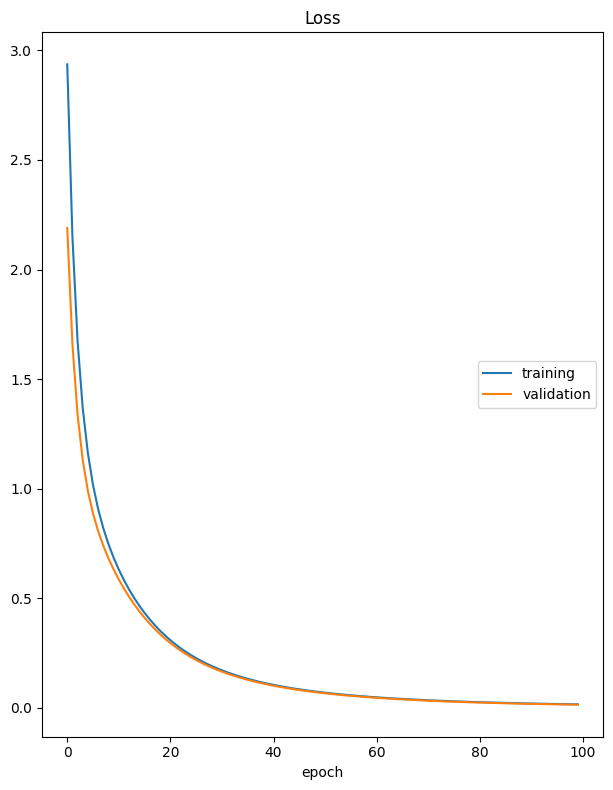

Loss
	training         	 (min:    0.015, max:    2.937, cur:    0.015)
	validation       	 (min:    0.014, max:    2.190, cur:    0.014)
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 262ms/step - loss: 0.0153 - val_loss: 0.0137


In [123]:
# Celda 1
from keras import backend as K

random.seed(42); np.random.seed(42); tf.random.set_seed(42)

K.clear_session()


# Definición red neuronal con la función Sequential()
model1 = Sequential()
# Definición de la capa densa con un tamaño de salida igual a output_var y un input_shape de dims
model1.add(Dense(output_var, input_shape=(dims,)))
# Definición de función de perdida. Se usa mean_squared_error dado que es un ejercicio de regresión
model1.compile(optimizer='sgd', loss='mean_squared_error')

RNN1 = model1.fit(X_train, Y_train, 
          verbose=True, 
          epochs=100, 
          batch_size=128,
          validation_data=(X_test,Y_test),
          callbacks=[PlotLossesKeras()])

In [124]:
# Impresión de la arquitectura de la red neuronal
print(model1.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (44.00 B)

 Trainable params: 8 (32.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

None


In [125]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

Y_pred = model1.predict(X_test)

mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)

print(f'MAE: {mae:.4f}')
print(f'MSE: {mse:.4f}')

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step 
MAE: 0.0949
MSE: 0.0137


Se escogieron 100 epocas, como el dataset es pequeño (500 observaciones totales, 350 de entrenamiento) y la red es muy simple, de 0 capas ocultas. 100 épocas es suficiente para que una red así converja sin overfitting. Se esocgió la función de perdida el mse ya que la variable objetivo es un número continuo entre 0 y 1 y el optimizador gradiente descendente ya que es el optimizador más fundamental que existe.

La gráfica muestra un comportamiento sano, ambas curvas bajan juntas y de forma suave, no hay separación grande entre training y validation, es decir no hay overfitting. La curva muestra una leve tendencia a seguir bajando cerca de época 100, sin embargo el experimento con 200 épocas confirmó que el modelo ya había convergido, la arquitectura lineal no tiene más capacidad para aprender.

En cuanto a los resultados, un MAE de 0.0949, en promedio, el modelo se equivoca en más o menos 0.0949 en la probablidad de admisión y con un MSE 0.0137, un valor bajo es buena señal. Es decir, si un estudiante tiene una probabilidad real de admisión de 0.75 (75%), el modelo predice en promedio entre 0.655 y 0.845. Para una red de una sola capa sin capas ocultas ni funciones de activación no lineales, este resultado es aceptable pero mejorable.

## Punto 2 - Red Neuronal multicapa

En la celda 2 creen una **red neuronal con dos capas** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

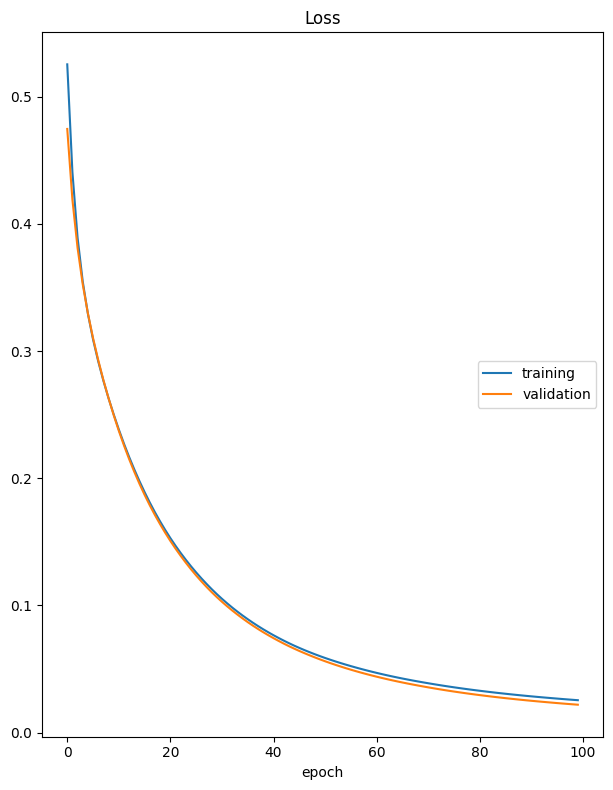

Loss
	training         	 (min:    0.025, max:    0.525, cur:    0.025)
	validation       	 (min:    0.022, max:    0.475, cur:    0.022)
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step - loss: 0.0254 - val_loss: 0.0219
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
MAE: 0.1154
MSE: 0.0219


In [126]:
# Celda 2
random.seed(42); np.random.seed(42); tf.random.set_seed(42)
K.clear_session()

model2 = Sequential()

# Capa oculta (nueva respecto al Punto 1)
model2.add(Dense(16, input_shape=(dims,), activation='relu'))
# Capa de salida (igual que Punto 1)
model2.add(Dense(output_var)) 

# Mismo optimizador, misma pérdida, mismas épocas → diferencia solo en arquitectura
model2.compile(optimizer='sgd', loss='mean_squared_error')

RNN2 = model2.fit(X_train, Y_train,
          verbose=True,
          epochs=100,
          batch_size=128,
          validation_data=(X_test, Y_test),
          callbacks=[PlotLossesKeras()])

Y_pred2 = model2.predict(X_test)
mae2 = mean_absolute_error(Y_test, Y_pred2)
mse2 = mean_squared_error(Y_test, Y_pred2)
print(f'MAE: {mae2:.4f}')
print(f'MSE: {mse2:.4f}')

In [127]:
print(model2.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147 (592.00 B)

 Trainable params: 145 (580.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

None


Se decide por 16 neuronas ya que el dataset solo tiene 350 filas de train y 7 variables, en el taller había 256 neuronas lo cual sería sobredimensionamiento y causaría overfitting. Se introduce en la capa oculta la función de activación ReLu para introducir no linealidad. Se conservan el mismo optimizador, la función de pérdida con respecto al punto 1, para que la única diferencia se la capa oculta.

La red de dos capas con optimizador SGD obtuvo un MAE de 0.1154 y MSE de 0.0219, resultados inferiores al modelo de una sola capa (MAE: 0.0949, MSE: 0.0137). Esto no significa que agregar una capa oculta sea perjudicial, sino que SGD no es el optimizador adecuado cuando la arquitectura introduce no linealidad con relu. El loss inicial de 0.525 evidencia que los pesos arrancaron en un punto desfavorable y SGD con learning rate fijo no logró converger eficientemente en 100 épocas. 

## Punto 3  - Red Neuronal multicapa

En la celda 3 creen **una red neuronal con más de una capa con la librería Keras, usando early stopping y dropout,** que prediga la probabilidad de admisión de los estudiantes con los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

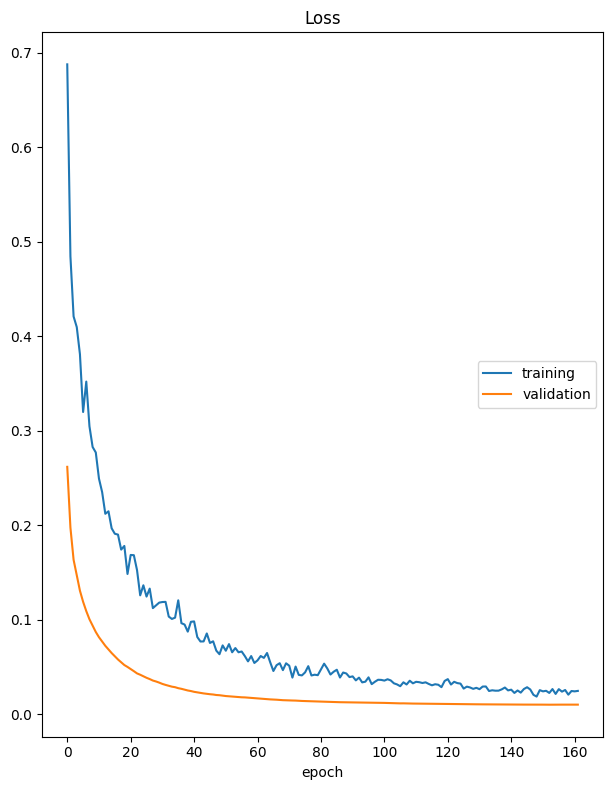

Loss
	training         	 (min:    0.019, max:    0.688, cur:    0.025)
	validation       	 (min:    0.010, max:    0.262, cur:    0.010)
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 261ms/step - loss: 0.0247 - val_loss: 0.0102
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
MAE: 0.0758
MSE: 0.0101


In [128]:
# Celda 3
from keras.callbacks import EarlyStopping

random.seed(42); np.random.seed(42); tf.random.set_seed(42)
K.clear_session()

model3 = Sequential()
model3.add(Dense(16, input_shape=(dims,), activation='relu'))
model3.add(Dropout(0.2))         # apaga 20% de neuronas aleatoriamente en cada paso
model3.add(Dense(16, activation='relu'))
model3.add(Dropout(0.2))
model3.add(Dense(output_var))    # salida lineal para regresión

model3.compile(optimizer='sgd', loss='mean_squared_error')
print(model3.summary())

# Definición del early stopping
early_stop = EarlyStopping(
    monitor='val_loss',   # observa la pérdida de validación
    patience=10,          # para si no mejora en 10 épocas seguidas
    restore_best_weights=True  # restaura los pesos del mejor momento
)

RNN3 = model3.fit(X_train, Y_train,
          verbose=True,
          epochs=200,            # épocas altas porque early stopping decide cuándo parar
          batch_size=128,
          validation_data=(X_test, Y_test),
          callbacks=[early_stop, PlotLossesKeras()])

Y_pred3 = model3.predict(X_test)
mae3 = mean_absolute_error(Y_test, Y_pred3)
mse3 = mean_squared_error(Y_test, Y_pred3)
print(f'MAE: {mae3:.4f}')
print(f'MSE: {mse3:.4f}')

Como podrán ver, quise mantener casi la misma arquitectura del punto inicial para comparar los cambios pedidos por los puntos siguientes. Podemos ver entonces este punto utilizó el mismo optimizador sgd pero obtuvo mejores resultados. Eso significa que el aporte real fue Dropout + Early Stopping, no el optimizador. Dropout evitó que la red memorizará el ruido de los datos en entrenamiento, forzándola a aprender patrones más generalizables. Early Stopping detuvo el entrenamiento en el momento óptimo antes de que empezara a sobre ajustarse.

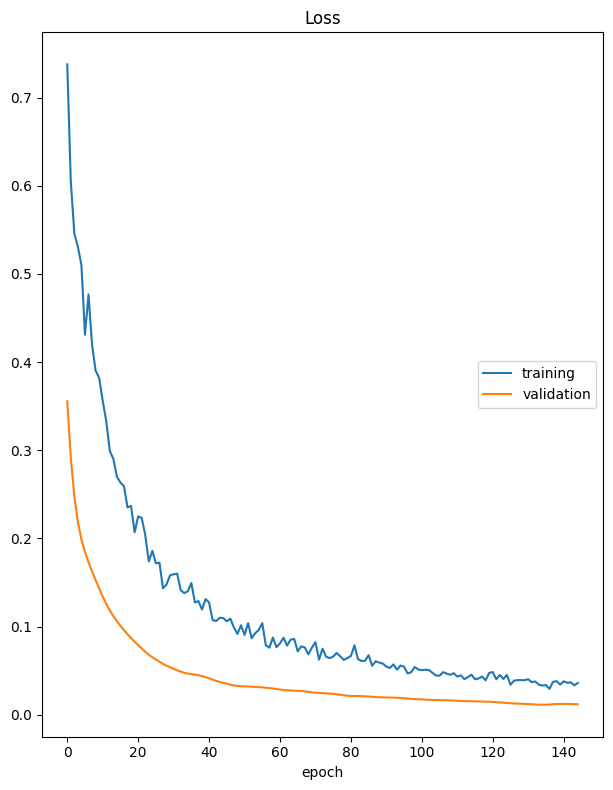

Loss
	training         	 (min:    0.029, max:    0.738, cur:    0.036)
	validation       	 (min:    0.011, max:    0.355, cur:    0.012)
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 255ms/step - loss: 0.0361 - val_loss: 0.0120
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
MAE: 0.0871
MSE: 0.0115


In [129]:
# Celda adicional - mismo modelo, solo cambia el optimizador
random.seed(42); np.random.seed(42); tf.random.set_seed(42)
K.clear_session()

model4 = Sequential()
model4.add(Dense(16, input_shape=(dims,), activation='relu'))
model4.add(Dropout(0.2))
model4.add(Dense(16, activation='relu'))
model4.add(Dropout(0.2))
model4.add(Dense(output_var))

model4.compile(optimizer='adam', loss='mean_squared_error')  # ← único cambio
print(model4.summary())

early_stop2 = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

RNN4 = model4.fit(X_train, Y_train,
          verbose=True,
          epochs=200,
          batch_size=128,
          validation_data=(X_test, Y_test),
          callbacks=[early_stop2, PlotLossesKeras()])

Y_pred4 = model4.predict(X_test)
mae4 = mean_absolute_error(Y_test, Y_pred4)
mse4 = mean_squared_error(Y_test, Y_pred4)
print(f'MAE: {mae4:.4f}')
print(f'MSE: {mse4:.4f}')

En el taller del profe vi que utilizó un optimizador llamado adam y según la documentación normalmente adam supera a sgd, por eso quise hacer este modelo adicional. Pero al parecer, en pequeños dataset como este (350 filas en train) puede ocurrir lo contrario porque adam adapta el learning rate por párametro por párametro, lo que en dataset pequeños puede llevarlo a sobreajustar más rápido antes de que el early stopping pueda reaccionar.

El modelo adicional con Adam (MAE: 0.0871, MSE: 0.0115) no superó al Punto 3 con SGD (MAE: 0.0758, MSE: 0.0101) bajo la misma arquitectura. 
Esto confirma que con datasets pequeños (350 filas), las técnicas de regularización pesan más que la elección del optimizador.

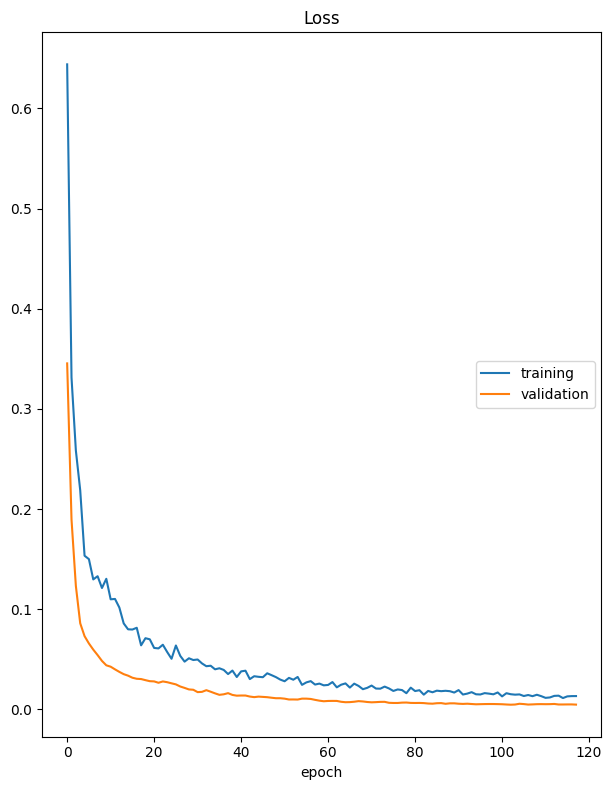

Loss
	training         	 (min:    0.011, max:    0.644, cur:    0.013)
	validation       	 (min:    0.005, max:    0.345, cur:    0.005)
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0132 - val_loss: 0.0047


In [130]:
random.seed(42); np.random.seed(42); tf.random.set_seed(42)
K.clear_session()

model_best = Sequential()
model_best.add(Dense(32, input_shape=(dims,), activation='relu'))
model_best.add(Dropout(0.2))
model_best.add(Dense(16, activation='relu'))  # segunda capa más pequeña
model_best.add(Dropout(0.2))
model_best.add(Dense(output_var))

model_best.compile(optimizer='adam', loss='mean_squared_error')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

RNN_best = model_best.fit(X_train, Y_train,
    epochs=200,
    batch_size=32,        # más pequeño que 128
    validation_data=(X_test, Y_test),
    callbacks=[early_stop, PlotLossesKeras()])

In [131]:
Y_pred5 = model_best.predict(X_test)
mae5 = mean_absolute_error(Y_test, Y_pred5)
mse5 = mean_squared_error(Y_test, Y_pred5)
print(f'MAE: {mae5:.4f}')
print(f'MSE: {mse5:.4f}')

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
MAE: 0.0537
MSE: 0.0046


Quise explorar la configuración de a mejor red para este dataset, por lo tanto se definio que una arquitectura que reduce neuronas progresivamente obliga a la red a comprimir la información en representaciones más esenciales, evitando memorizar ruido, por eso una capa tiene 32 y la siguiente 16.Los Dropouts de 0.2 en ambas capas, con tan pocos datos el riesgo de overfitting es alto. 0.2 es conservador, apaga el 20% de neuronas aleatoriamente en cada paso sin destruir la capacidad de aprendizaje. Para batch_size=32 en lugar de 128, con 128 el modelo ve muy pocos lotes por época dado el tamaño del dataset. Con 32 ve más variedad en cada época, lo cual ayuda a generalizar mejor con datos concentrados como Chance of Admit.Para patience=15, con SGD usamos 10 y funcionó. Con Adam que converge más rápido, 15 da más margen para detectar si una mejora temporal es real o fluctuación.

## Punto 4 - Comparación y análisis de resultados

En la celda 4 comparen los resultados obtenidos de las diferentes redes y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

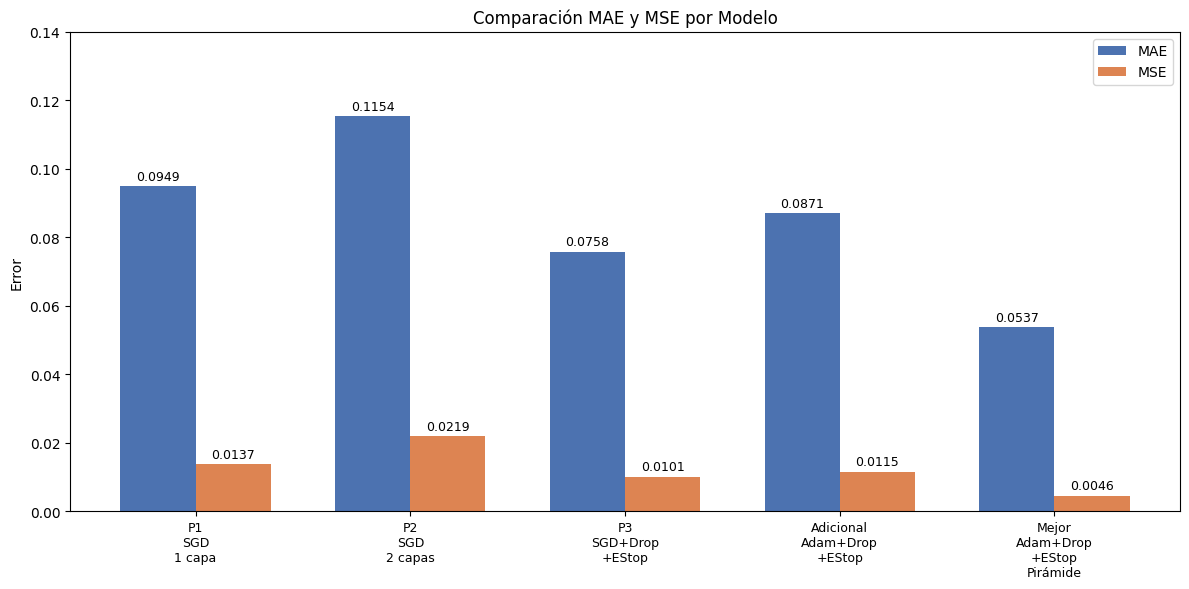

In [132]:
# Celda 4

modelos = ['P1\nSGD\n1 capa', 'P2\nSGD\n2 capas', 
           'P3\nSGD+Drop\n+EStop', 'Adicional\nAdam+Drop\n+EStop', 
           'Mejor\nAdam+Drop\n+EStop\nPirámide']

mae_vals = [0.0949, 0.1154, 0.0758, 0.0871, 0.0537]
mse_vals = [0.0137, 0.0219, 0.0101, 0.0115, 0.0046]

x = np.arange(len(modelos))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, mae_vals, width, label='MAE', color='#4C72B0')
bars2 = ax.bar(x + width/2, mse_vals, width, label='MSE', color='#DD8452')

# Etiquetas de valor sobre cada barra
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Error')
ax.set_title('Comparación MAE y MSE por Modelo')
ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=9)
ax.legend()
ax.set_ylim(0, 0.14)
plt.tight_layout()
plt.show()


| Modelo | Optimizador | Capas ocultas | Dropout | Early Stopping | MAE | MSE |
|---|---|---|---|---|---|---|
| Punto 1 - 1 capa lineal | SGD | 0 | No | No | 0.0949 | 0.0137 |
| Punto 2 - 2 capas       | SGD | 1 | No | No | 0.1154 | 0.0219 |
| Punto 3 - 2 capas       | SGD | 2 | Sí | Sí | 0.0758 | 0.0101 |
| Adicional - 2 capas     | Adam| 2 | Sí | Sí | 0.0871 | 0.0115 |
| Mejor - pirámide 32→16  | Adam| 2 | Sí | Sí | **0.0537** | **0.0046** |

### Análisis de resultados

El modelo con peor desempeño fue el **Punto 2** (MAE: 0.1154, MSE: 0.0219). 
Aunque introduce una capa oculta con relu, el optimizador SGD no logró 
navegar eficientemente la superficie de error más compleja, arrancando 
con un loss inicial de 0.525 y sin lograr converger en 100 épocas.

El mejor modelo fue la **red pirámide 32→16 con Adam, Dropout y Early 
Stopping** (MAE: 0.0537, MSE: 0.0046), con una mejora del 66% en MSE 
respecto al baseline del Punto 1. Sus ventajas principales son tres: 
la arquitectura decreciente comprime la información progresivamente, 
el Dropout evita memorizar ruido con tan pocos datos, y el Early Stopping 
detuvo el entrenamiento en el momento óptimo (época 115) antes de que 
el overfitting se volviera significativo.

Un hallazgo relevante es que en el **Punto 3**, SGD con Dropout y Early 
Stopping superó al modelo adicional con Adam bajo la misma arquitectura, 
lo que evidencia que las técnicas de regularización aportan más que el 
optimizador cuando el dataset es pequeño (350 filas de entrenamiento).

Se hizo un pequeño experimento aumentando para el punto 1 y 2 las épocas de 100 a 200, pero más épocas solo ayudan cuando el modelo todavía tiene capacidad de aprender y el optimizador puede moverse. Si ya convergió como el punto 1 o está atascado como el punto 2, son épocas desperdiciadas. Por eso el Early Stopping del Punto 3 es tan valioso, detecta exactamente cuándo el entrenamiento adicional deja de aportar.